In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import os
os.environ['R_HOME'] = 'D:/Program Files/R-4.5.0' #@TODO include in some setup file

from simulation_engine.scenarios.iv.binary_iv import BinaryIV
from simulation_engine.scenarios.conf.binary_conf import BinaryConf
from simulation_engine.scenarios.iv.continuous_iv import ContinuousIV
from simulation_engine.util.plotting_util import PlottingUtil

import pandas as pd
pd.set_option('display.max_columns', None)

#disable warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import matplotlib.pyplot as plt
import seaborn as sns
import math
# from linearmodels.iv import IV2SLS
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.neural_network import MLPClassifier
# Train a decision tree classifier to predict 'tightest_bounds'
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from simulation_engine.util.plotting_util import PlottingUtil
pd.options.mode.chained_assignment = None  # default='warn'
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import numpy as np




In [18]:
import re

#setup
results = pd.read_pickle('17_06/results.pkl')
binaryConf = BinaryConf(results)
#target b_X_Y = 2.003502
results[(results['b_X_Y'] >= 1.999) & (results['b_X_Y'] <= 2.004)]

,seed,intercept_X,intercept_Y,b_U_X,b_X_Y,b_U_Y,ATE_true,PNS_true,p_Y1_mean,p_Y0_mean,p_U,U,X,Y,epsilon_X,sigma_X_vec,epsilon_Y,sigma_Y_vec,entropy_U,entropy_X,entropy_Y,squasher_X_name,squasher_Y_name,heteroskedasticity_structure,ATE_OLS-0.99_bound_lower,ATE_OLS-0.99_bound_upper,ATE_OLS-0.99_bound_valid,ATE_OLS-0.99_bound_width,ATE_OLS-0.99_bound_failed,ATE_OLS-0.98_bound_lower,ATE_OLS-0.98_bound_upper,ATE_OLS-0.98_bound_valid,ATE_OLS-0.98_bound_width,ATE_OLS-0.98_bound_failed,ATE_OLS-0.95_bound_lower,ATE_OLS-0.95_bound_upper,ATE_OLS-0.95_bound_valid,ATE_OLS-0.95_bound_width,ATE_OLS-0.95_bound_failed,ATE_causaloptim_bound_lower,ATE_causaloptim_bound_upper,ATE_causaloptim_bound_valid,ATE_causaloptim_bound_width,ATE_causaloptim_bound_failed,PNS_causaloptim_bound_lower,PNS_causaloptim_bound_upper,PNS_causaloptim_bound_valid,PNS_causaloptim_bound_width,PNS_causaloptim_bound_failed,ATE_autobound_bound_lower,ATE_autobound_bound_upper,ATE_autobound_bound_valid,ATE_autobound_bound_width,ATE_autobound_bound_failed,PNS_autobound_bound_lower,PNS_autobound_bound_upper,PNS_autobound_bound_valid,PNS_autobound_bound_width,PNS_autobound_bound_failed,ATE_entropybounds-0.80_bound_lower,ATE_entropybounds-0.80_bound_upper,ATE_entropybounds-0.80_bound_valid,ATE_entropybounds-0.80_bound_width,ATE_entropybounds-0.80_bound_failed,ATE_entropybounds-0.80_theta,ATE_entropybounds-0.20_bound_lower,ATE_entropybounds-0.20_bound_upper,ATE_entropybounds-0.20_bound_valid,ATE_entropybounds-0.20_bound_width,ATE_entropybounds-0.20_bound_failed,ATE_entropybounds-0.20_theta,ATE_entropybounds-0.10_bound_lower,ATE_entropybounds-0.10_bound_upper,ATE_entropybounds-0.10_bound_valid,ATE_entropybounds-0.10_bound_width,ATE_entropybounds-0.10_bound_failed,ATE_entropybounds-0.10_theta,PNS_entropybounds-0.80_bound_lower,PNS_entropybounds-0.80_bound_upper,PNS_entropybounds-0.80_bound_valid,PNS_entropybounds-0.80_bound_width,PNS_entropybounds-0.80_bound_failed,PNS_entropybounds-0.80_theta,PNS_entropybounds-0.20_bound_lower,PNS_entropybounds-0.20_bound_upper,PNS_entropybounds-0.20_bound_valid,PNS_entropybounds-0.20_bound_width,PNS_entropybounds-0.20_bound_failed,PNS_entropybounds-0.20_theta,PNS_entropybounds-0.10_bound_lower,PNS_entropybounds-0.10_bound_upper,PNS_entropybounds-0.10_bound_valid,PNS_entropybounds-0.10_bound_width,PNS_entropybounds-0.10_bound_failed,PNS_entropybounds-0.10_theta,PNS_entropybounds-trueTheta_bound_lower,PNS_entropybounds-trueTheta_bound_upper,PNS_entropybounds-trueTheta_bound_valid,PNS_entropybounds-trueTheta_bound_width,PNS_entropybounds-trueTheta_bound_failed,PNS_entropybounds-trueTheta_theta,ATE_entropybounds-trueTheta_bound_lower,ATE_entropybounds-trueTheta_bound_upper,ATE_entropybounds-trueTheta_bound_valid,ATE_entropybounds-trueTheta_bound_width,ATE_entropybounds-trueTheta_bound_failed,ATE_entropybounds-trueTheta_theta,PNS_entropybounds-randomTheta_bound_lower,PNS_entropybounds-randomTheta_bound_upper,PNS_entropybounds-randomTheta_bound_valid,PNS_entropybounds-randomTheta_bound_width,PNS_entropybounds-randomTheta_bound_failed,PNS_entropybounds-randomTheta_theta,ATE_entropybounds-randomTheta_bound_lower,ATE_entropybounds-randomTheta_bound_upper,ATE_entropybounds-randomTheta_bound_valid,ATE_entropybounds-randomTheta_bound_width,ATE_entropybounds-randomTheta_bound_failed,ATE_entropybounds-randomTheta_theta,ATE_zaffalonbounds_bound_lower,ATE_zaffalonbounds_bound_upper,ATE_zaffalonbounds_bound_valid,ATE_zaffalonbounds_bound_width,ATE_zaffalonbounds_bound_failed,PNS_zaffalonbounds_bound_lower,PNS_zaffalonbounds_bound_upper,PNS_zaffalonbounds_bound_valid,PNS_zaffalonbounds_bound_width,PNS_zaffalonbounds_bound_failed,ATE_manski_bound_lower,ATE_manski_bound_upper,ATE_manski_bound_width,ATE_manski_bound_failed,ATE_manski_bound_valid,ATE_tianpearl_bound_lower,ATE_tianpearl_bound_upper,ATE_tianpearl_bound_width,ATE_tianpearl_bound_failed,ATE_tianpearl_bound_valid,PNS_tianpearl_bound_lower,PNS_tianpearl_bound_upper,PNS_tianpearl_bound_width,PNS_tianpearl_bo

In [20]:
sj_interest = BinaryConf._generate_data(n=500, b_U_X=1, b_U_Y=-1, b_X_Y=2, intercept_X=0.3, intercept_Y=-0.5, p_U=0.6, squasher_X_name='sigmoid', squasher_Y_name='sigmoid')

In [ ]:
dataset = []

for i in range(2000):
    sj_interest = BinaryConf._generate_data(n=500, b_U_X=1, b_U_Y=-1, b_X_Y=2, intercept_X=0.3, intercept_Y=-0.5, p_U=0.6, squasher_X_name='sigmoid', squasher_Y_name='sigmoid')
    dataset.append(sj_interest)
df = pd.DataFrame(dataset)

scenario = BinaryConf(df)
ATE_algs = ['ATE_OLS-0.99',
 'ATE_OLS-0.98',
 'ATE_OLS-0.95',
 'ATE_causaloptim',
 'ATE_autobound',
 'ATE_entropybounds-0.80',
 'ATE_entropybounds-0.20',
 'ATE_entropybounds-0.10',
 'ATE_entropybounds-trueTheta',
 'ATE_entropybounds-randomTheta',
 'ATE_zaffalonbounds',
 'ATE_tianpearl',
 'ATE_manski']
PNS_algs = ['PNS_causaloptim',
 'PNS_autobound',
 'PNS_entropybounds-0.80',
 'PNS_entropybounds-0.20',
 'PNS_entropybounds-0.10',
 'PNS_entropybounds-trueTheta',
 'PNS_entropybounds-randomTheta',
 'PNS_zaffalonbounds',
 'PNS_tianpearl']
scenario.get_algorithms('PNS')
# scenario.run(['PNS_tianpearl'])

['PNS_causaloptim',
 'PNS_autobound',
 'PNS_entropybounds-0.80',
 'PNS_entropybounds-0.20',
 'PNS_entropybounds-0.10',
 'PNS_entropybounds-trueTheta',
 'PNS_entropybounds-randomTheta',
 'PNS_zaffalonbounds',
 'PNS_tianpearl']

count    2000.000000
mean        0.676578
std         0.022011
min         0.614000
25%         0.662000
50%         0.676000
75%         0.692000
max         0.732000
Name: PNS_tianpearl_bound_width, dtype: float64

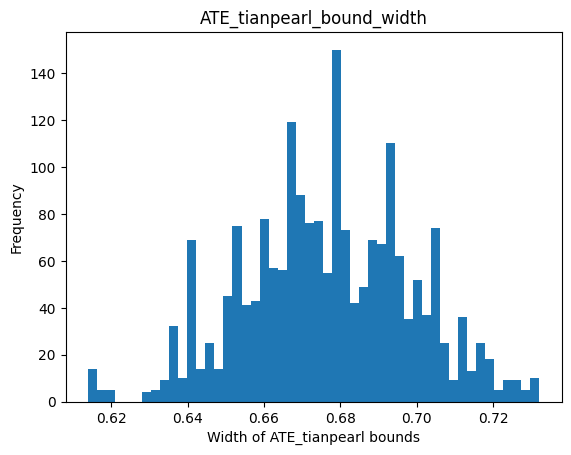

In [36]:
scenario.data['PNS_tianpearl_bound_width'].plot(kind='hist', bins=50, title='ATE_tianpearl_bound_width', xlabel='Width of ATE_tianpearl bounds', ylabel='Frequency')
scenario.data['PNS_tianpearl_bound_width'].describe()

In [37]:
scenario.data['PNS_tianpearl_bound_valid'].value_counts()

PNS_tianpearl_bound_valid
True    2000
Name: count, dtype: int64